### Load data in using the same logic as data exploration

In [65]:
import os
import glob
import pandas as pd
import numpy as np

%matplotlib inline

DATA_ROOT = os.path.join("data", "ami")
SUMMARY_DIR = os.path.join(DATA_ROOT, "summary")
TRANSCRIPT_DIR = os.path.join(DATA_ROOT, "transcript")

In [66]:
def parse_transcript(filepath):
    # this function parses the transcript files text and discards the parts we aren't using,
    #   such as the speaker and timestamps.
    
    # All the actual spoken words of the transcripts are added to this array.
    utterances = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")

            if len(parts) != 4:
                print('Transcript line parts mismatch')
                continue

            # even though it's a text file, it's basically set up like a csv with tab separated columns
            speaker, start_time, text, section = parts

            utterances.append({
                "speaker": speaker,
                "start_time": float(start_time),
                "text": text,
                "section": section
            })

    utterance_df = pd.DataFrame(utterances)

    # blank transcripts are ignored (should be none)
    if len(utterance_df) == 0:
        return "", utterance_df

    # Build full transcript text
    transcript_text = " ".join(utterance_df["text"].tolist())
    
    return transcript_text, utterance_df

In [67]:
def load_transcripts(transcript_dir):
    records = []

    # loading all of the sets now and adding a column to show which each row belongs to
    for split in ["train", "valid", "test"]:
        split_dir = os.path.join(transcript_dir, split)

        # check all files in the dir, treat file names as meeting IDs
        for filepath in glob.glob(os.path.join(split_dir, "*.txt")):
            meeting_id = os.path.basename(filepath).replace(".txt", "")

            transcript_text, utterance_df = parse_transcript(filepath)

            records.append({
                "meeting_id": meeting_id,
                "split": split,
                "transcript": transcript_text,
                
                # didn't end up using this
                # "num_utterances": len(utterance_df),
                # "num_speakers": utterance_df["speaker"].nunique()
            })

    return pd.DataFrame(records)

In [68]:
def build_dataset():
    df = load_transcripts(TRANSCRIPT_DIR)

    summaries = {}
    for filepath in glob.glob(os.path.join(SUMMARY_DIR, "*.txt")):
        meeting_id = os.path.basename(filepath).replace(".txt", "")

        with open(filepath, "r", encoding="utf-8") as f:
            # summary files are simpler than transcripts, just need to read the whole vfile
            summaries[meeting_id] = f.read()

    # attach summaries
    df["summary"] = df["meeting_id"].map(summaries)
    
    # get the transcript and summary lengths in words, and the ratio of summary length to transcript length
    # we also tested character counts, but the ratios were very similar to word counts
    df['transcript_length'] = df['transcript'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['summary_length'] = df['summary'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['ratio_summary_to_transcript'] = df.apply(lambda row: row['summary_length'] / row['transcript_length'] if row['transcript_length'] > 0 else 0, axis=1)

    return df

In [69]:
df = build_dataset()

print(df.shape)
print(df.head())

(137, 7)
  meeting_id  split                                         transcript  \
0    ES2002a  train  Okay . Right . Um well this is the kick-off me...   
1    ES2002b  train  Is that alright now ? Okay . Sorry ? Okay , ev...   
2    ES2002c  train  'S to do now is to decide how to fulfil what y...   
3    ES2002d  train  Okay we all all set ? Right . Well this is the...   
4    ES2005a  train  Uh , making a profit of fifty million Euros . ...   

                                             summary  transcript_length  \
0  The project manager introduced the upcoming pr...               3105   
1  The project manager briefed the team on some n...               8109   
2  The project manager recapped the decisions mad...               8757   
3  The project manager recapped the decisions mad...               9061   
4  The group discussed their initial ideas about ...                891   

   summary_length  ratio_summary_to_transcript  
0             128                     0.041224

In [70]:
# print and example just to check
print(df['summary'][0])

The project manager introduced the upcoming project to the team members and then the team members participated in an exercise in which they drew their favorite animal and discussed what they liked about the animal.
The project manager talked about the project finances and selling prices.
The team then discussed various features to consider in making the remote.
The industrial designer will work on the working design of the remote.
The user interface designer will work on the technical functions of the remote.
The marketing executive will work on what requirements the remote has to fulfill
The remote will sell for 25 Euro.
The remote will be sold on an international scale.
The production costs cannot exceed 12.50 Euro.
Whether the remote will be used exclusively for televisions.



### Making a custom Dataset class to handling chunking of transcripts, maps each chunk to the summary, and tokenizes the inputs / target summary.

I referenced https://blog.roboflow.com/pytorch-custom-dataset/ for this part of the code.

In [71]:
import torch

# need a custom dataset to handle transcript chunking
class MeetingSummarizationDataset(torch.utils.data.Dataset):
    """
    Each meeting transcript is split into overlapping chunks so that
    it fits within the model's maximum input length.
    This allows training on long transcripts that would exceed token limits.
    """

    def __init__(
        self,
        df,
        tokenizer,
        max_input_tokens=512,
        max_target_tokens=424,  # number determined based on 95 percentile of summary lengtths (found in EDA)
        stride=128
    ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_input_tokens = max_input_tokens
        self.max_target_tokens = max_target_tokens
        self.stride = stride

        # This will store all (meeting, chunk) pairs
        self.samples = []

        # Each chunk of each meeting becomes a separate training example so we can treat long documents as many smaller training samples.
        for idx, row in self.df.iterrows():

            # Skip rows without summaries (should be none)
            if not isinstance(row["summary"], str):
                continue

            # each row has a transcript, chunks are that but broken up
            chunks = self._chunk_text(row["transcript"])

            for chunk_tokens in chunks:
                # df index lets us go from a chunk back to its row in the original df
                self.samples.append({
                    "df_idx": idx,
                    "chunk_tokens": chunk_tokens
                })

    def _chunk_text(self, text):
        """
        Splits a long transcript into overlapping token chunks.
        Overlap helps preserve context across chunks
        """
        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        chunks = []
        start = 0

        while start < len(tokens):
            end = start + self.max_input_tokens
            
            # start and end are the indexes to use for the chunk
            chunk_tokens = tokens[start:end]
            chunks.append(chunk_tokens)

            # Move forward less than a chunk size to create overlap
            start += (self.max_input_tokens - self.stride)

        return chunks

    def __len__(self):
        """Total number of chunks across all meetings."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Returns one training example: (input chunk, summary)
        """
        sample = self.samples[idx]
        row = self.df.iloc[sample["df_idx"]]

        # Convert token chunk back to text for standard tokenizer processing
        input_text = self.tokenizer.decode(
            sample["chunk_tokens"],
            skip_special_tokens=True
        )

        # Tokenize input (transcript chunk)
        model_inputs = self.tokenizer(
            input_text,
            max_length=self.max_input_tokens,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Tokenize target (full summary)
        target = self.tokenizer(
            row["summary"],
            max_length=self.max_target_tokens,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Remove batch dimension added by tokenizer
        # TODO This seems to work but I'm a bit confused by the batching.
        # Seems to me this will run really slow since we aren't using any batching, but idk how to fix that since __getitem__ has to return just one
        input_ids = model_inputs["input_ids"].squeeze(0)
        attention_mask = model_inputs["attention_mask"].squeeze(0)
        labels = target["input_ids"].squeeze(0)

        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,

            # including the meeting ID so we can later use it to map eval info
            "meeting_id": row["meeting_id"]
        }

In [72]:
from transformers import AutoTokenizer

model_name = "facebook/bart-base"

# using the default tokenizer / settigns until I have a reason not to
tokenizer = AutoTokenizer.from_pretrained(model_name)

c:\Users\andre\anaconda3\envs\Group4\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [73]:
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]

# TODO remove after testing!
# USING A SUBSET OF DATA TO DEBUG THE MODEL
# train_subset = set(train_df["meeting_id"].unique()[:3])
# train_df = train_df[train_df["meeting_id"].isin(train_subset)]

# valid_subset = set(train_df["meeting_id"].unique()[:3])
# valid_df = train_df[train_df["meeting_id"].isin(valid_subset)]

# put our data into the custom Dataset we made
train_dataset = MeetingSummarizationDataset(train_df, tokenizer)
valid_dataset = MeetingSummarizationDataset(valid_df, tokenizer)

print(len(train_dataset))
print(len(valid_dataset))


1588
337


Print out some info and an example for debugging

In [74]:
print(len(train_dataset))

sample = train_dataset[0]

print(tokenizer.decode(sample["input_ids"]))
print("\n--- TARGET ---\n")
print(tokenizer.decode(
    [t for t in sample["labels"] if t != -100]
))

1588
<s>Okay. Right. Um well this is the kick-off meeting for our our project. Um and um this is just what we're gonna be doing over the next twenty five minutes. Mm-hmm. Um so first of all, just to kind of make sure that we all know each other, I'm Laura and I'm the project manager. Do you want to introduce yourself again? Great. Hi, I'm David and I'm supposed to be an industrial designer. Okay. And I'm Andrew and I'm uh our marketing expert. Um I'm Craig and I'm User Interface. Great. Okay. Um so we're designing a new remote control and um Oh I have to record who's here actually. So that's David, Andrew and Craig, isn't it? And you all arrived on time. Um yeah so des uh design a new remote control. Um, as you can see it's supposed to be original, trendy and user friendly. Um so that's kind of our our brief, as it were. Um and so there are three different stages to the design. Um I'm not really sure what what you guys have already received um in your emails. What did you get? Um, I ju

### Next we need to prep several pieces for model training

In [75]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

In [76]:
# batch = next(iter(train_loader))

# print(batch["input_ids"].shape)
# print(batch["labels"].shape)

In [77]:
from transformers import (
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq
)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Collator is used just to handle padding dynamically for batches while training
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [78]:
import evaluate

rouge = evaluate.load("rouge")

# this function will be used to compute and display metrics while training, every x steps or epochs
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # handle logits vs generated tokens
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # If preds are logits take argmax
    if predictions.ndim == 3:
        predictions = predictions.argmax(axis=-1)
        
    # debug logs, no longer needed
    # print(preds.shape)
    # print(preds.min(), preds.max())

    # Replace -100 in predictions and labels
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return scores

In [ ]:
from transformers import Seq2SeqTrainingArguments
import torch

# configure all the many training arguments for the trainer, mostly using sensible defaults
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",

    # training
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,

    # Evaluation
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,

    # logging
    logging_steps=50,
    logging_dir="./logs",
    report_to="tensorboard",

    # Seq2Seq specific
    predict_with_generate=True,
    generation_max_length=128,
    generation_num_beams=4,

    # performance
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,

    # Using a seed to make it reproducible
    seed=42
)

c:\Users\andre\anaconda3\envs\Group4\lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [80]:
from transformers import Seq2SeqTrainer

# define the Trainer itself, using all the pieces we just set up
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

c:\Users\andre\anaconda3\envs\Group4\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


##### Since we've broken the transcripts down into chunks, we need to combine the summaries generated for chunks together to form the full summary for a given transcript.


In [81]:
from collections import defaultdict
import evaluate

rouge = evaluate.load("rouge")

# generate pairs of meeting level predicted summaries (from chunk lvl preds) and their associated reference aka label summaries
def generate_meeting_level_summaries(model, dataset, tokenizer, device):
    model.eval()
    model.to(device)

    # create a map of meeting_id -> chunk list, defaultdict will initialize with empty list each meeting_id
    meeting_chunks = defaultdict(list)

    # go through the dataset to group chunks by their meeting id
    for i in range(len(dataset)):
        item = dataset[i]
        meeting_chunks[item["meeting_id"]].append(item)

    predictions = {}
    references = {}

    # get the chunk level summary for each chunk of a given meeting
    # then join them together to form a meeting level summary
    for meeting_id, chunks in meeting_chunks.items():
        chunk_outputs = []

        for item in chunks:
            # have to unsqueeze bc of batching dimension
            input_ids = item["input_ids"].unsqueeze(0).to(device)
            attention_mask = item["attention_mask"].unsqueeze(0).to(device)

            # generate the model's prediction for chunk level summary
            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=128,
                    num_beams=4
                )

            # turn the token outputs back into text
            text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
            chunk_outputs.append(text)

        # Simple aggregation, just joining all chunks together
        # TODO more sophisticated agg functions are possible but mor complicated
        final_prediction = " ".join(chunk_outputs)

        predictions[meeting_id] = final_prediction

        references[meeting_id] = tokenizer.decode(
            # this looks weird but it's just a way to get the label summary back out
            [t for t in chunks[0]["labels"] if t != -100],
            skip_special_tokens=True
        )

    return predictions, references

from transformers import TrainerCallback

# define a trainer callback to basically print extra metrics,
# but these ones are meeting level metrics instead of chunk level
class MeetingLevelEvalCallback(TrainerCallback):
    def __init__(self, eval_dataset, tokenizer):
        self.eval_dataset = eval_dataset
        self.tokenizer = tokenizer

    def on_evaluate(self, args, state, control, model=None, **kwargs):
        # debug logs
        # print("KWARGS KEYS:", kwargs.keys())
        # metrics = kwargs.get("metrics", None)
        # print("METRICS BEFORE:", metrics)
        
        device = model.device

        # generate meeting level summaries for the val set of data
        predictions, reference_labels = generate_meeting_level_summaries(
            model,
            self.eval_dataset,
            self.tokenizer,
            device
        )

        pred_list = list(predictions.values())
        ref_list = list(reference_labels.values())

        # compute rouge scores comparing meeting level instead of chunk level summaries
        scores = rouge.compute(
            predictions=pred_list,
            references=ref_list,
            use_stemmer=True
        )

        # Log in Trainer loop
        print("\n=== Meeting-Level ROUGE ===")
        for k, v in scores.items():
            print(f"{k}: {v:.4f}")

        # Add to Trainer logs for later graphing
        logs = {
            "meeting_rouge1": scores["rouge1"],
            "meeting_rouge2": scores["rouge2"],
            "meeting_rougeL": scores["rougeL"],
            "epoch": state.epoch,
            "step": state.global_step
        }
        state.log_history.append(logs)

        return control

# register the callback to run during training
trainer.add_callback(
    MeetingLevelEvalCallback(valid_dataset, tokenizer)
)

### Train the model

In [82]:
trainer.train()

  1%|          | 5/594 [00:01<03:38,  2.70it/s]

{'loss': 5.2719, 'grad_norm': 5.967386722564697, 'learning_rate': 2.97979797979798e-05, 'epoch': 0.03}


  2%|▏         | 10/594 [00:03<03:40,  2.65it/s]

{'loss': 4.1749, 'grad_norm': 4.9428629875183105, 'learning_rate': 2.9545454545454545e-05, 'epoch': 0.05}


  3%|▎         | 15/594 [00:05<03:36,  2.68it/s]

...

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}



=== Meeting-Level ROUGE ===
rouge1: 0.2182
rouge2: 0.0902
rougeL: 0.1345
rougeLsum: 0.2114


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
100%|██████████| 594/594 [25:31<00:00,  2.58s/it]

{'train_runtime': 1531.995, 'train_samples_per_second': 3.11, 'train_steps_per_second': 0.388, 'train_loss': 1.8525022216116138, 'epoch': 2.99}


TrainOutput(global_step=594, training_loss=1.8525022216116138, metrics={'train_runtime': 1531.995, 'train_samples_per_second': 3.11, 'train_steps_per_second': 0.388, 'total_flos': 1448733824778240.0, 'train_loss': 1.8525022216116138, 'epoch': 2.9924433249370277})

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# trainer log printouts for debugging
logs = trainer.state.log_history
df = pd.DataFrame(logs)
df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,...,eval_samples_per_second,eval_steps_per_second,meeting_rouge1,meeting_rouge2,meeting_rougeL,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,5.2719,5.967387,0.000030,0.025189,5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.1749,4.942863,0.000030,0.050378,10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.7466,3.995807,0.000029,0.075567,15,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.4166,3.643866,0.000029,0.100756,20,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.2259,3.587939,0.000029,0.125945,25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Eval and interpret model results

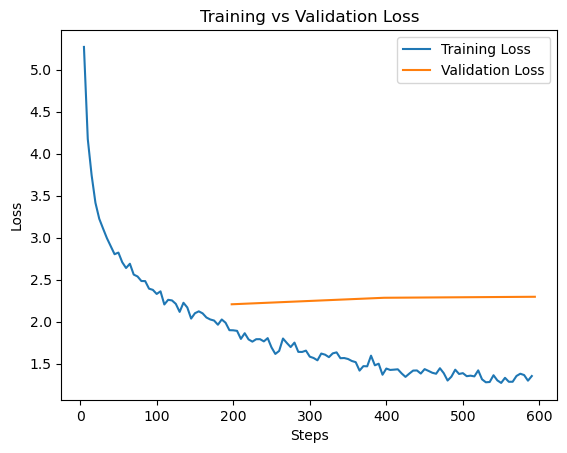

In [84]:

train_logs = df[df["loss"].notna()]
eval_logs = df[df["eval_loss"].notna()]

plt.figure()

plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

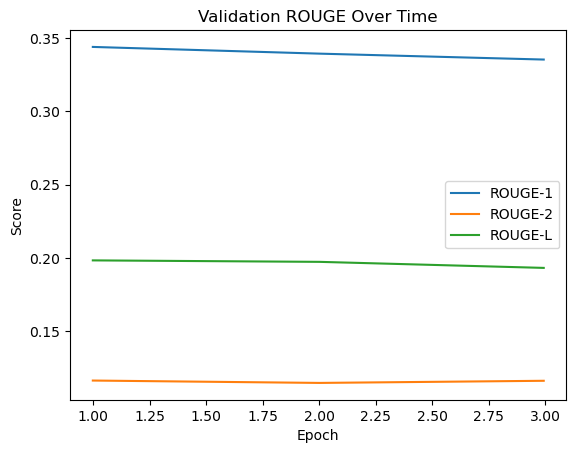

In [85]:
plt.figure()

eval_rouge = df[df["eval_rougeL"].notna()]

plt.plot(eval_rouge["epoch"], eval_rouge["eval_rouge1"], label="ROUGE-1")
plt.plot(eval_rouge["epoch"], eval_rouge["eval_rouge2"], label="ROUGE-2")
plt.plot(eval_rouge["epoch"], eval_rouge["eval_rougeL"], label="ROUGE-L")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation ROUGE Over Time")
plt.legend()
plt.show()

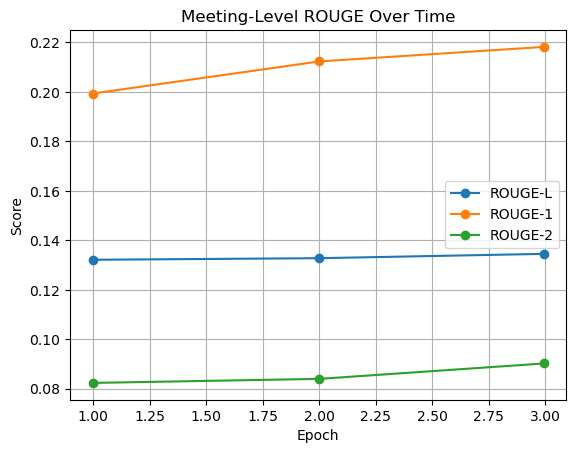

In [86]:
meeting_logs = df[df["meeting_rougeL"].notna()]

plt.figure()

plt.plot(meeting_logs["epoch"], meeting_logs["meeting_rougeL"], marker='o', label="ROUGE-L")
plt.plot(meeting_logs["epoch"], meeting_logs["meeting_rouge1"], marker='o', label="ROUGE-1")
plt.plot(meeting_logs["epoch"], meeting_logs["meeting_rouge2"], marker='o', label="ROUGE-2")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Meeting-Level ROUGE Over Time")
plt.legend()

plt.grid(True)
plt.show()

In [87]:
model.eval()
device = next(model.parameters()).device

predictions, labels = generate_meeting_level_summaries(
    model,
    valid_dataset,
    tokenizer,
    device
)


In [88]:

print(len(predictions))
print(len(labels))

20
20


In [89]:
print(labels['ES2003a'])

The team members introduced themselves to each other by name and by their roles in the project.
The project manager introduced the upcoming project to the team and then the team members participated in an exercise in which they drew their favorite animal and discussed why they liked the animal.
The project manager discussed the project finances and selling prices.
The team then discussed various features to consider in producing the remote such as gaming options, an LCD screen, and combining functionality so as to control multiple devices.
The team will decide how the user interface will work
The remote will cost 12.50 Euro to produce.
The remote will sell for 25 Euro.
The remote will feature an ergonomic design.
Putting an LCD screen on the remote.
Having a remote that controls multiple devices.
Having a joystick on the remote.



In [90]:
import random

meeting_ids = list(predictions.keys())
prediction_label_ratio = [len(predictions[m_id]) / len(labels[m_id]) for m_id in meeting_ids]
sample_ids = random.sample(meeting_ids, k=3)

# print some example labels vs their predicted summaries

for m_id in sample_ids:
    print("=" * 100)
    print(f"Meeting ID: {m_id}")
    print("=" * 100)

    print("\n--- LABEL ---\n")
    print(labels[m_id][:])

    print("\n--- PREDICTION ---\n")
    print(predictions[m_id][:])
    

Meeting ID: ES2003d

--- LABEL ---

The project manager recapped the decisions made in the previous meeting and two team members presented a prototype for the remote the team is designing and discussed its ergonomic appearance and its features.
The marketing expert began to lead the team in conducting an evaluation of the prototype but was interrupted when the project manager shifted the discussion to examining the production costs of the team's product.
The original specifications of the team's product proved to be too expensive and so the team had to discuss which features to lose and which to maintain in order to meet the target cost.
After discussing costs, the team returned to conducting their product evaluation.
The prototype was evaluated on the basis of its ability to be located when misplaced, ease of use, appearance, technological innovativeness, and sponginess.
Overall, the prototype received average marks.
The team then evaluated the project process, finding that they were 

From the displayed example summaries I can see that predicted summaries are sometimes much longer than the reference label summary. There also seem to be some repeated information in the generated predictions, likely due to the stride of the transcript chunking.

In [91]:
prediction_label_ratio

[5.399524375743163,
 7.689090909090909,
 10.352619233776387,
 10.044935262757045,
 5.4356884057971016,
 4.6360310928212165,
 5.390821986888553,
 5.462437395659433,
 3.8643312101910827,
 4.0913884007029875,
 4.1873015873015875,
 4.100309323906319,
 4.44320987654321,
 7.17384916748286,
 7.120247148288973,
 8.856619890176937,
 4.704304869442484,
 7.151358950328023,
 9.854925373134328,
 10.33768352365416]

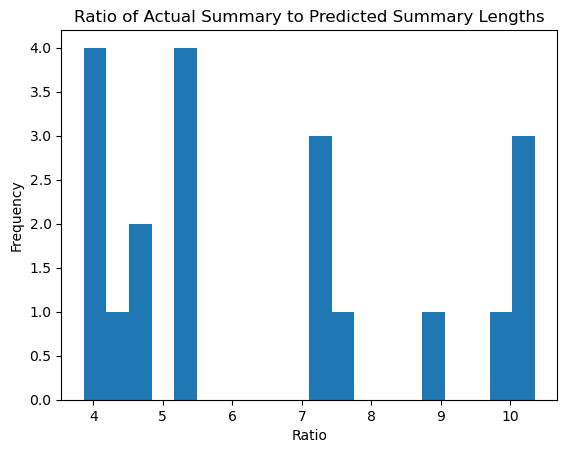

In [92]:
plt.hist(prediction_label_ratio, bins=20)
plt.title("Ratio of Actual Summary to Predicted Summary Lengths")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

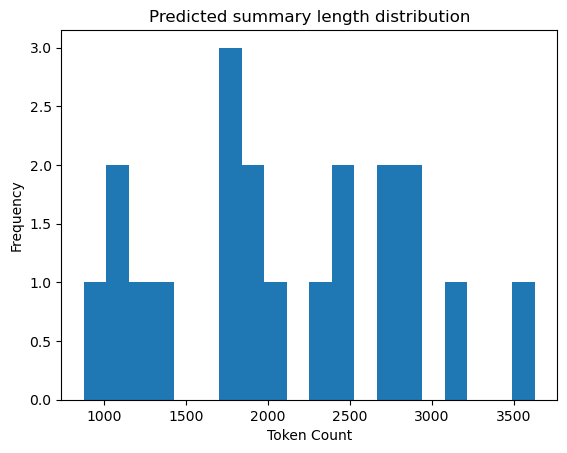

In [96]:
plt.hist([len(tokenizer.encode(x)) for x in predictions.values()], bins=20)
plt.title("Predicted summary length distribution")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

{'ES2003a': 'The project manager opens the meeting by stating the agenda for the next meeting.\nThe industrial designer begins talking about the interior workings of a remote control.\nHe talks about the possibility of using an LCD screen to display the relevant information.\nShe suggests using a scroll wheel instead of a joystick.\nThey discuss using a kinetic battery instead of kinetic energy.\nFinally, the marketing expert presents, talking about user requirements and how to incorporate these requirements into the design of the remote.\nNext, the user interface designer presents, explaining how a remote works and showing examples of existing remotes.\nAfter that, the industrial designer The project manager opens the meeting by stating the agenda for the next meeting.\nThe industrial designer begins the discussion about the interior workings of a remote control device.\nHe suggests that the remote should be small, easy to use, have a locator function, and be easy to navigate.\nThey d